# EDA for Tarla Dalal Dataset

Number of recipes: 691
Columns: ['name', 'region', 'ingredients', 'instructions']
Regions: ['South Indian' 'North Indian' 'Bengal' 'Gujarati' 'Rajasthani'
 'Maharashtrian' 'Punjabi']
Null values: name            0
region          0
ingredients     0
instructions    0
dtype: int64


<ipython-input-4-d6d88823b127>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="region", order=df['region'].value_counts().index, palette="viridis")


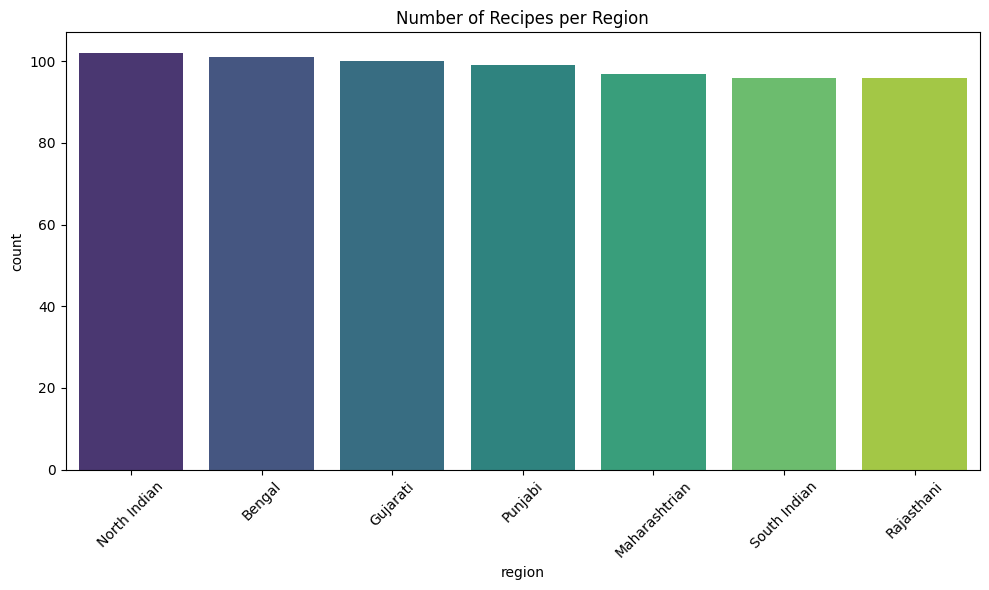

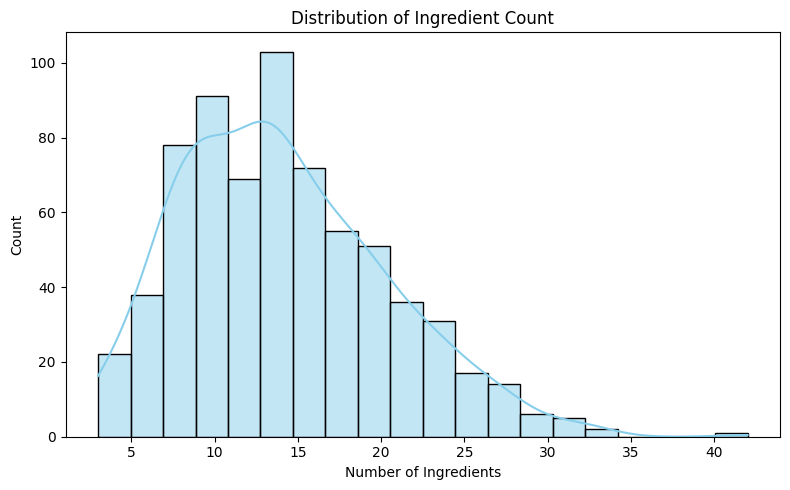

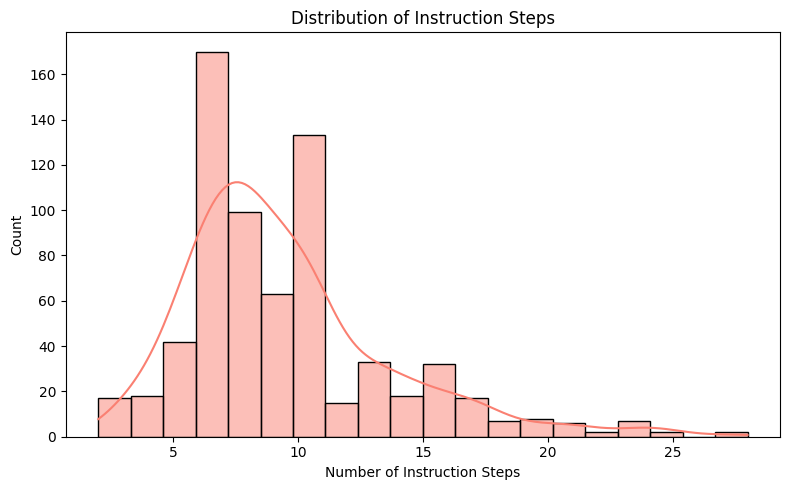

<ipython-input-4-d6d88823b127>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=common_df, x="Count", y="Ingredient", palette="magma")


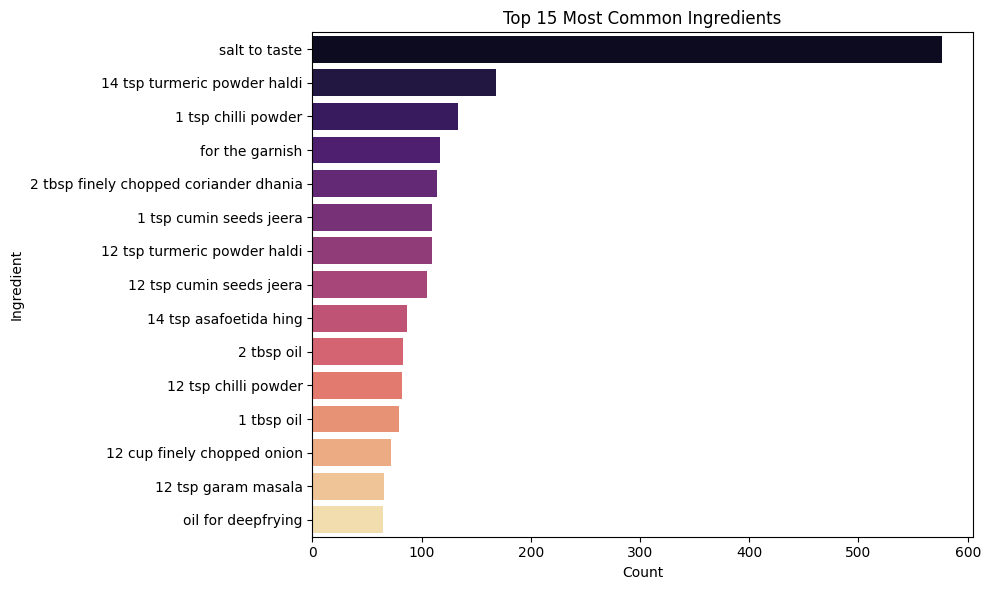

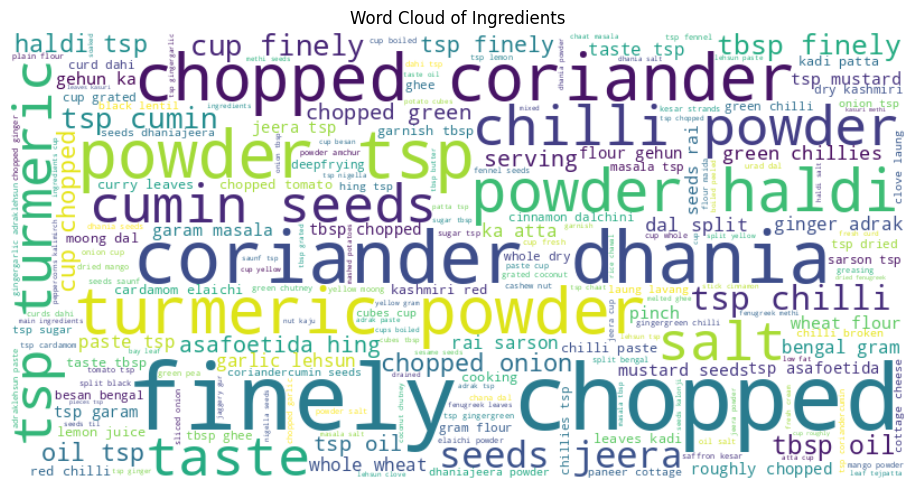

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# Load the cleaned Tarla Dalal data
with open("cleaned_tarla_dalal.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Basic info
print("Number of recipes:", len(df))
print("Columns:", df.columns.tolist())
print("Regions:", df['region'].unique())

# Check nulls
print("Null values:", df.isnull().sum())

# Recipe count per region
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="region", order=df['region'].value_counts().index, palette="viridis")
plt.title("Number of Recipes per Region")
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig("eda_region_count.png")
plt.show()

# Ingredient count distribution
df["num_ingredients"] = df["ingredients"].apply(lambda x: len(x))
plt.figure(figsize=(8,5))
sns.histplot(df["num_ingredients"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Ingredient Count")
plt.xlabel("Number of Ingredients")
plt.tight_layout()
#plt.savefig("eda_ingredient_dist.png")
plt.show()

# Instruction step count
df["num_steps"] = df["instructions"].apply(lambda x: len(x))
plt.figure(figsize=(8,5))
sns.histplot(df["num_steps"], bins=20, kde=True, color="salmon")
plt.title("Distribution of Instruction Steps")
plt.xlabel("Number of Instruction Steps")
plt.tight_layout()
#plt.savefig("eda_instruction_dist.png")
plt.show()

# Most common ingredients
all_ingredients = [ing.lower() for sublist in df["ingredients"] for ing in sublist]
common_ing = Counter(all_ingredients).most_common(15)
common_df = pd.DataFrame(common_ing, columns=["Ingredient", "Count"])

plt.figure(figsize=(10,6))
sns.barplot(data=common_df, x="Count", y="Ingredient", palette="magma")
plt.title("Top 15 Most Common Ingredients")
plt.tight_layout()
#plt.savefig("eda_top_ingredients.png")
plt.show()

# Wordcloud of ingredients
ingredient_text = " ".join(all_ingredients)
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(ingredient_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Ingredients")
plt.tight_layout()
#plt.savefig("eda_wordcloud.png")
plt.show()
